In [1]:
!pip install pygimli tetgen
!sudo apt install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0
  libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2 libteckit0
  libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern pfb2t1c2pfb
  poppler-data preview-latex-style rake ruby ruby-net-telnet ruby-rubygems
  ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils tex-common
  tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf ghostscript-x
  libavalon-framework-java l

# 2D Refraction modelling and inversion

In [2]:
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt
import matplotlib.pyplot as plt

from latex import latexify
latexify(columns=2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Model setup

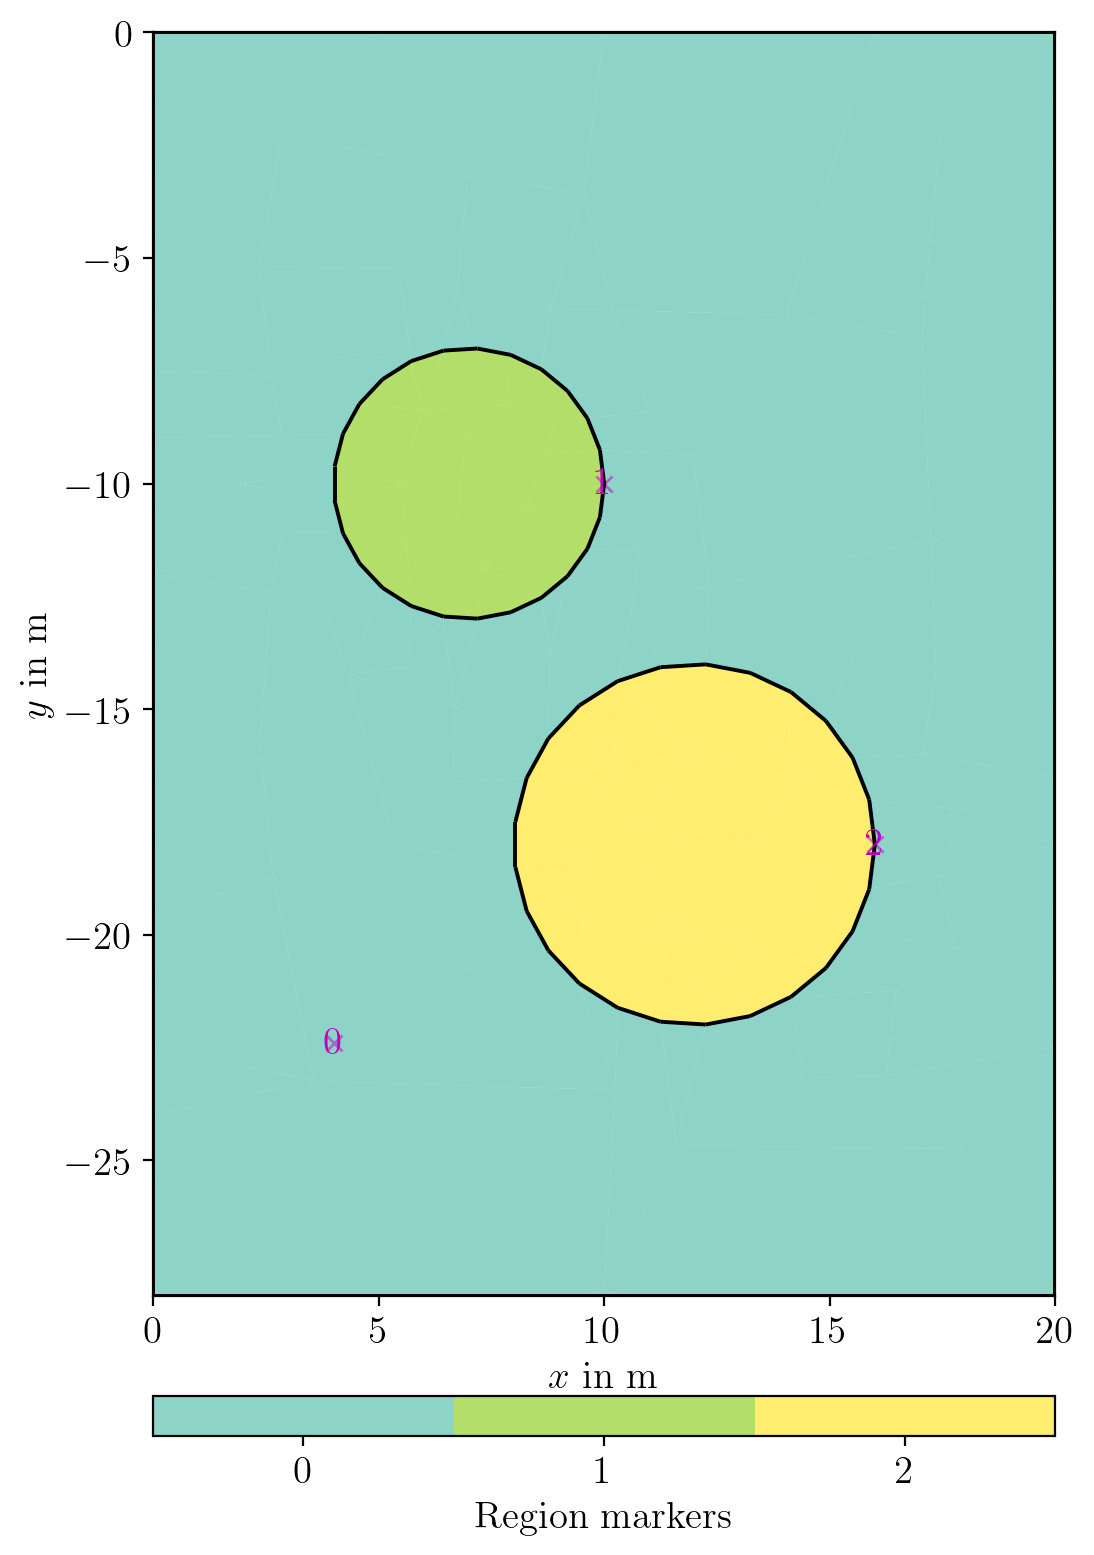

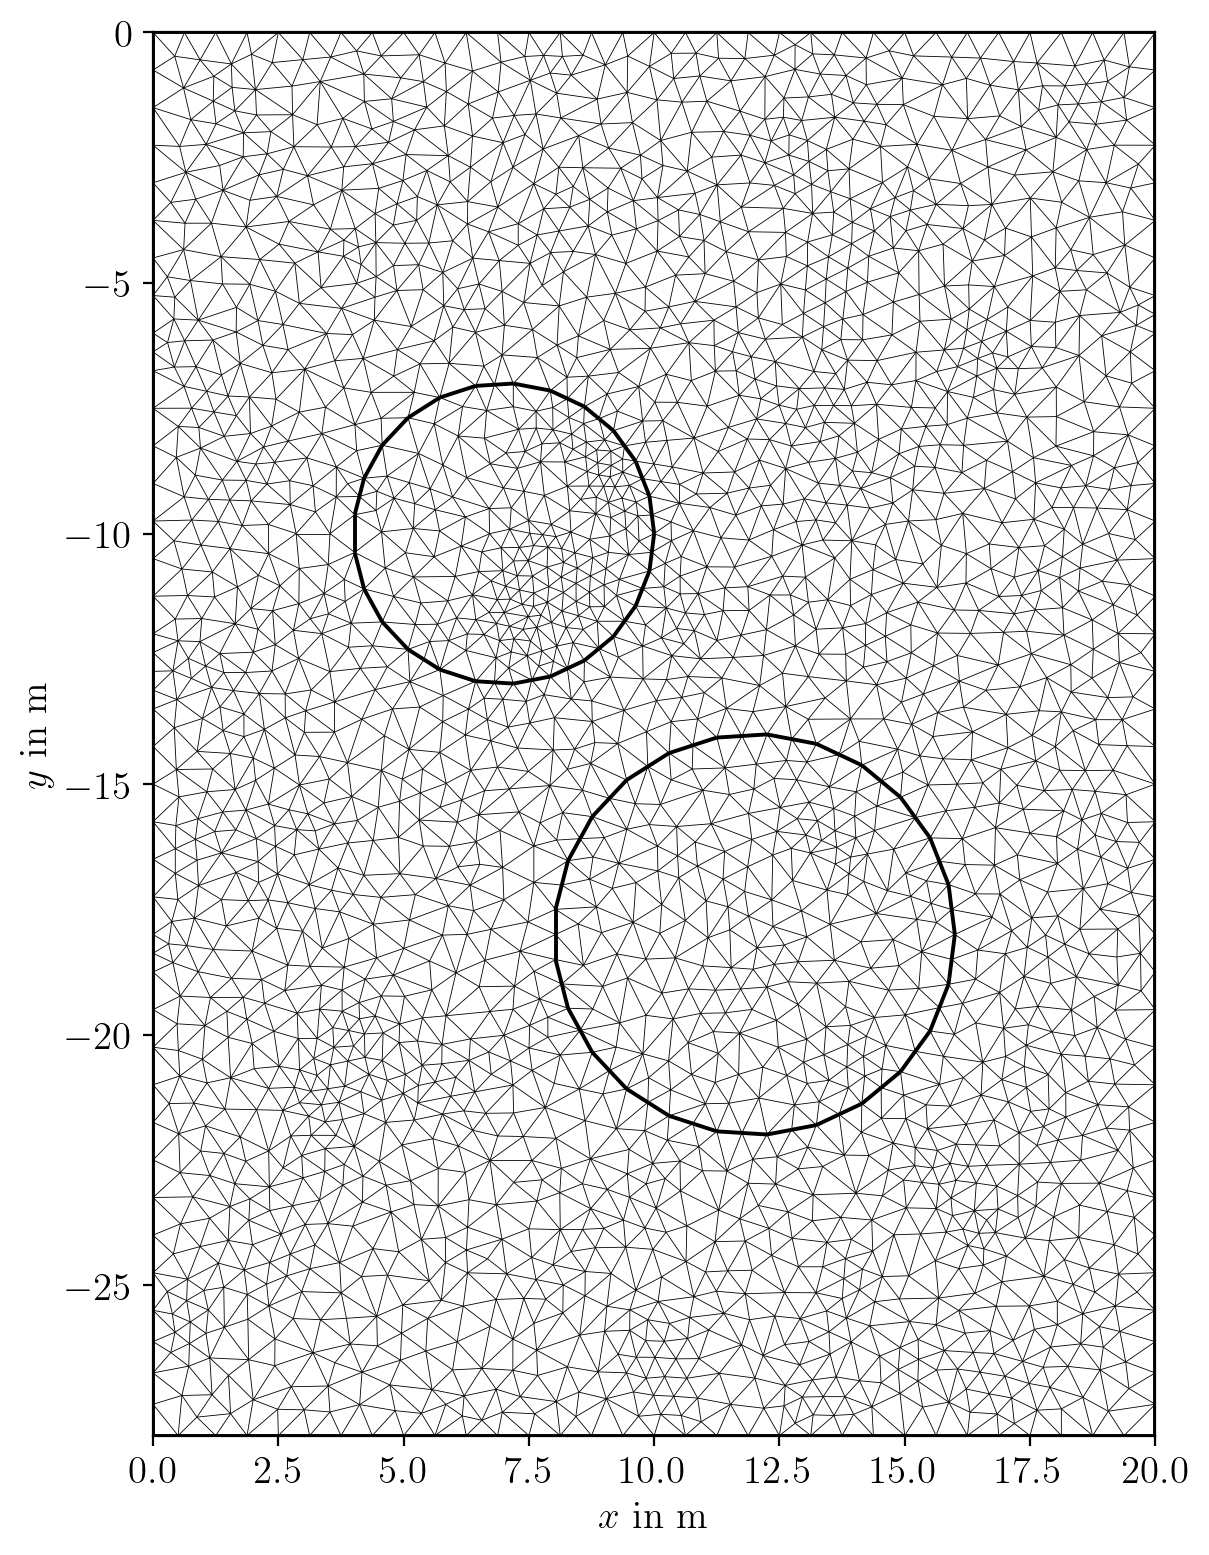

In [28]:
bh_spacing = 20.0
bh_length = 25.0
sensor_spacing = 1.5

world = mt.createRectangle(start=[0, -(bh_length + 3)], end=[bh_spacing, 0.0],
                           marker=0)

depth = -np.arange(sensor_spacing, bh_length + sensor_spacing, sensor_spacing)

sensors = np.zeros((len(depth) * 2, 2))  # two boreholes
sensors[len(depth):, 0] = bh_spacing  # x
sensors[:, 1] = np.hstack([depth] * 2)

c0 = mt.createCircle(pos=(7.0, -10.0), radius=3, nSegments=25, marker=1)
c1 = mt.createCircle(pos=(12.0, -18.0), radius=4, nSegments=25, marker=2)
geom = world + c0 + c1
for sen in sensors:
    geom.createNode(sen)

mesh_fwd = mt.createMesh(geom, quality=34, area=0.25)

fig, ax = plt.subplots(figsize=(12, 8))
pg.show(geom, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
ax, _ = pg.show(mesh_fwd, ax=ax)
plt.show()

## Synthetic data generation

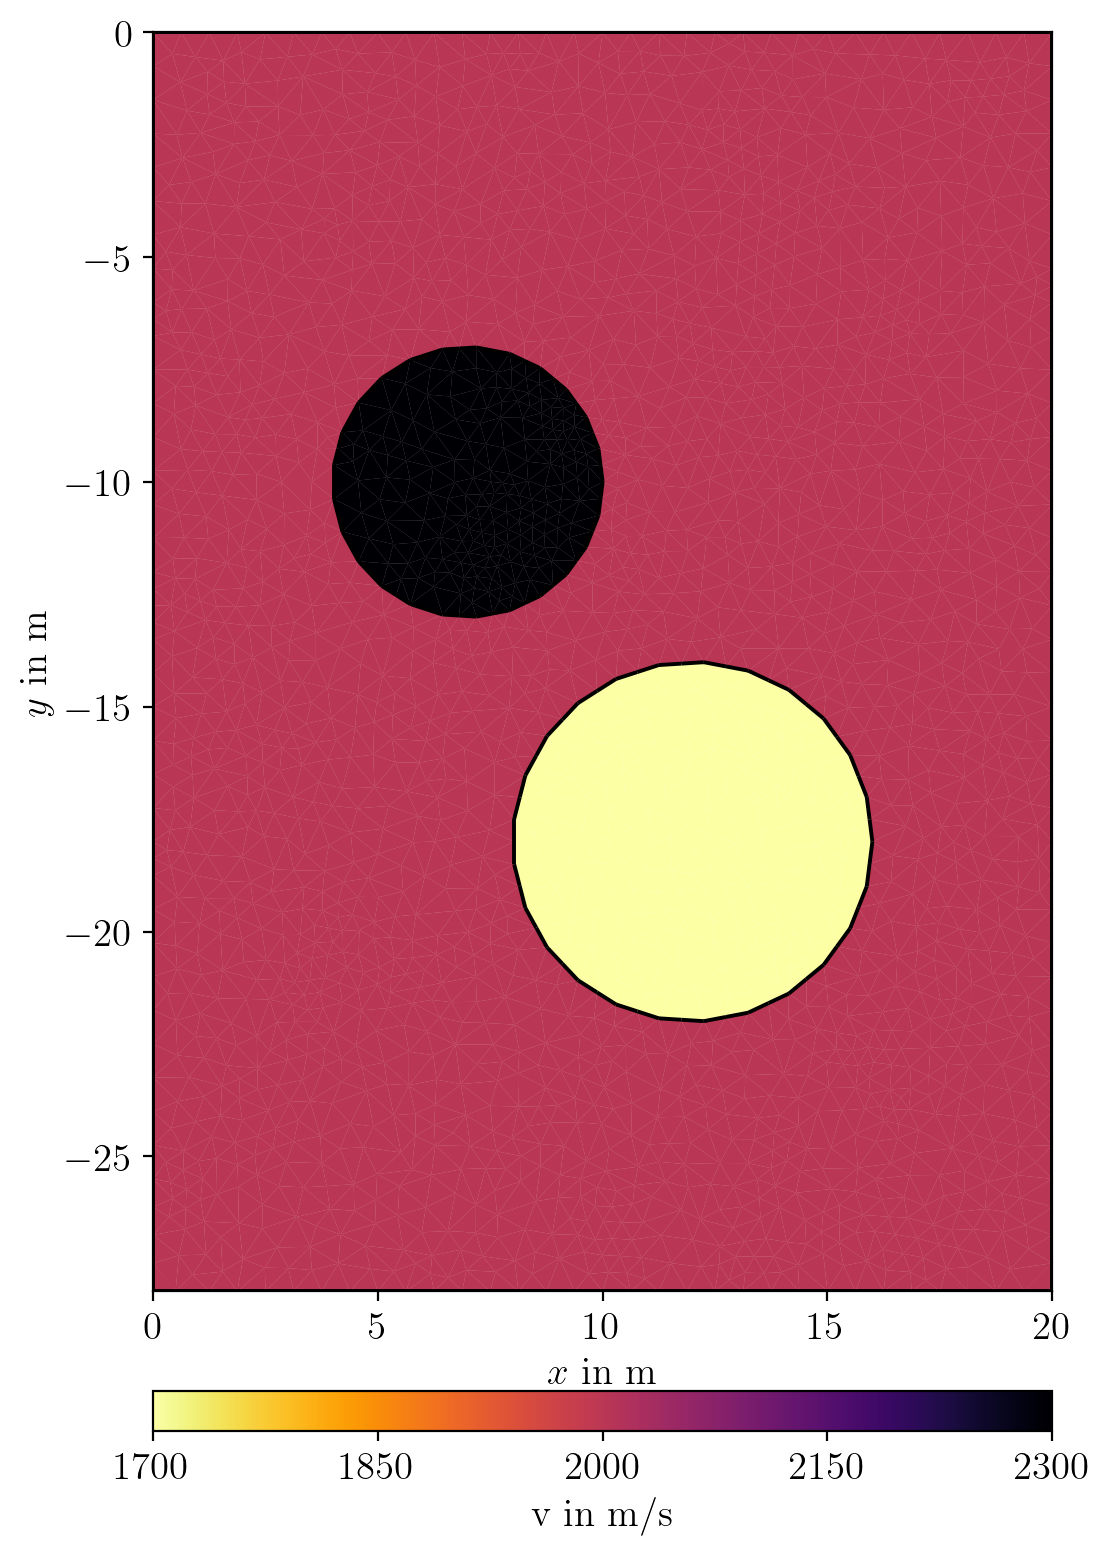

In [29]:
model = np.array([2000., 2300, 1700])[mesh_fwd.cellMarkers()]

fig, ax = plt.subplots(figsize=(12, 8))
ax, _ = pg.show(mesh_fwd, model, colorBar=True, logScale=False, label='v in m/s', ax=ax, nlevels=3, cMap="inferno_r")
# pg.viewer.mpl.drawSensors(ax, scheme.sensors(), diam=1.0,
#                          facecolor='white', edgecolor='black')

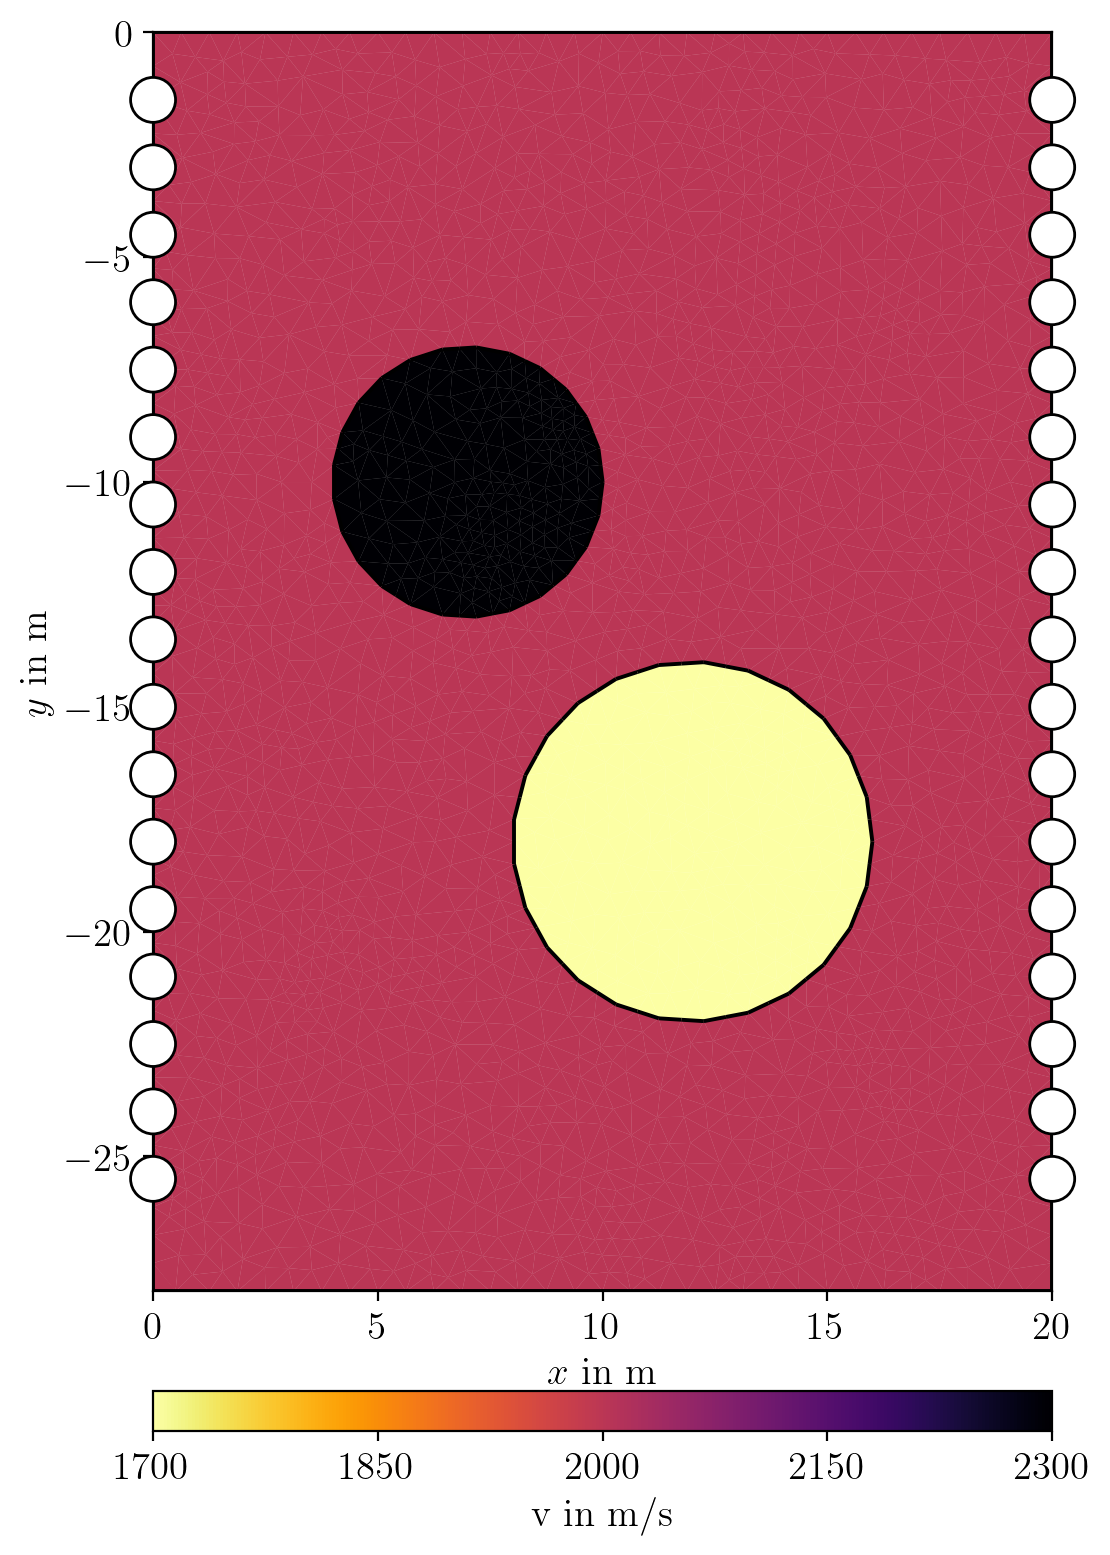

In [30]:
scheme = tt.createCrossholeData(sensors)
fig, ax = plt.subplots(figsize=(12, 8))
ax, _ = pg.show(mesh_fwd, model, colorBar=True, logScale=False, label='v in m/s', ax=ax, nlevels=3, cMap="inferno_r")
pg.viewer.mpl.drawSensors(ax, scheme.sensors(), diam=1.0,
                         facecolor='white', edgecolor='black')

INFO:pyGIMLi:Creating refined mesh (secnodes: 4) to solve forward task.
06/11/25 - 17:40:19 - pyGIMLi - INFO - Creating refined mesh (secnodes: 4) to solve forward task.


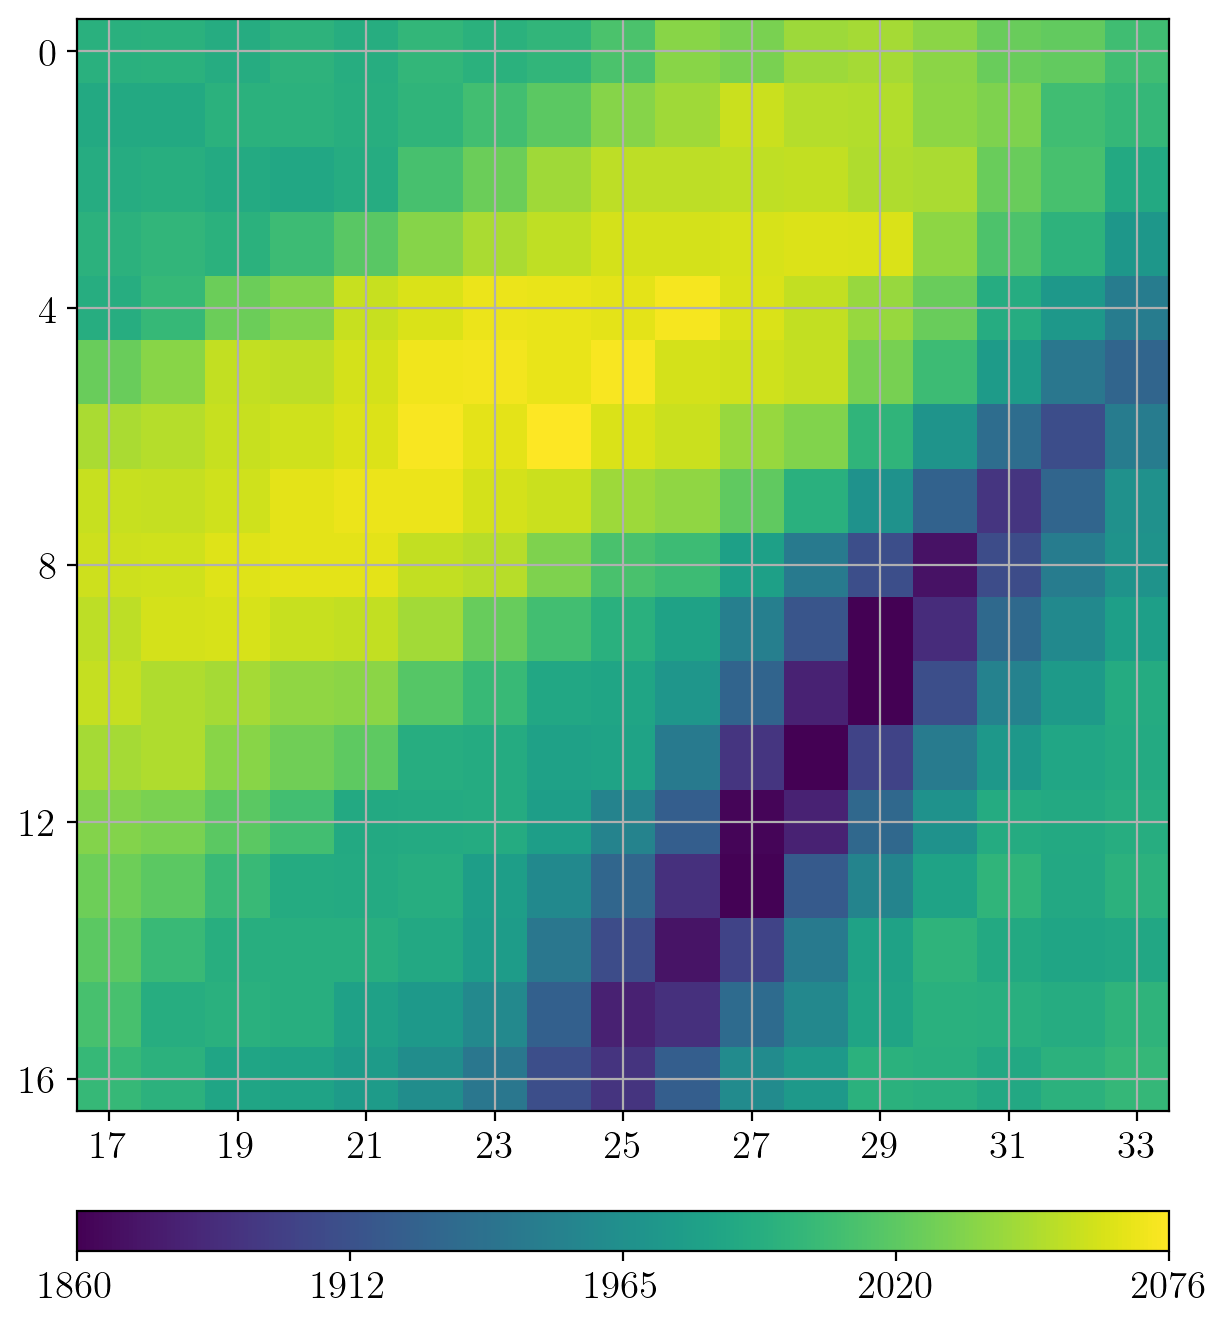

In [31]:
mgr = tt.TravelTimeManager()
data = tt.simulate(mesh=mesh_fwd, scheme=scheme, slowness=1./model,
                   secNodes=4, noiseLevel=0.001, noiseAbs=1e-5, seed=1337)
fig, ax = plt.subplots(figsize=(12, 8))
ax, cb = tt.showVA(data, usePos=False, ax=ax)
plt.show()

## Inversion

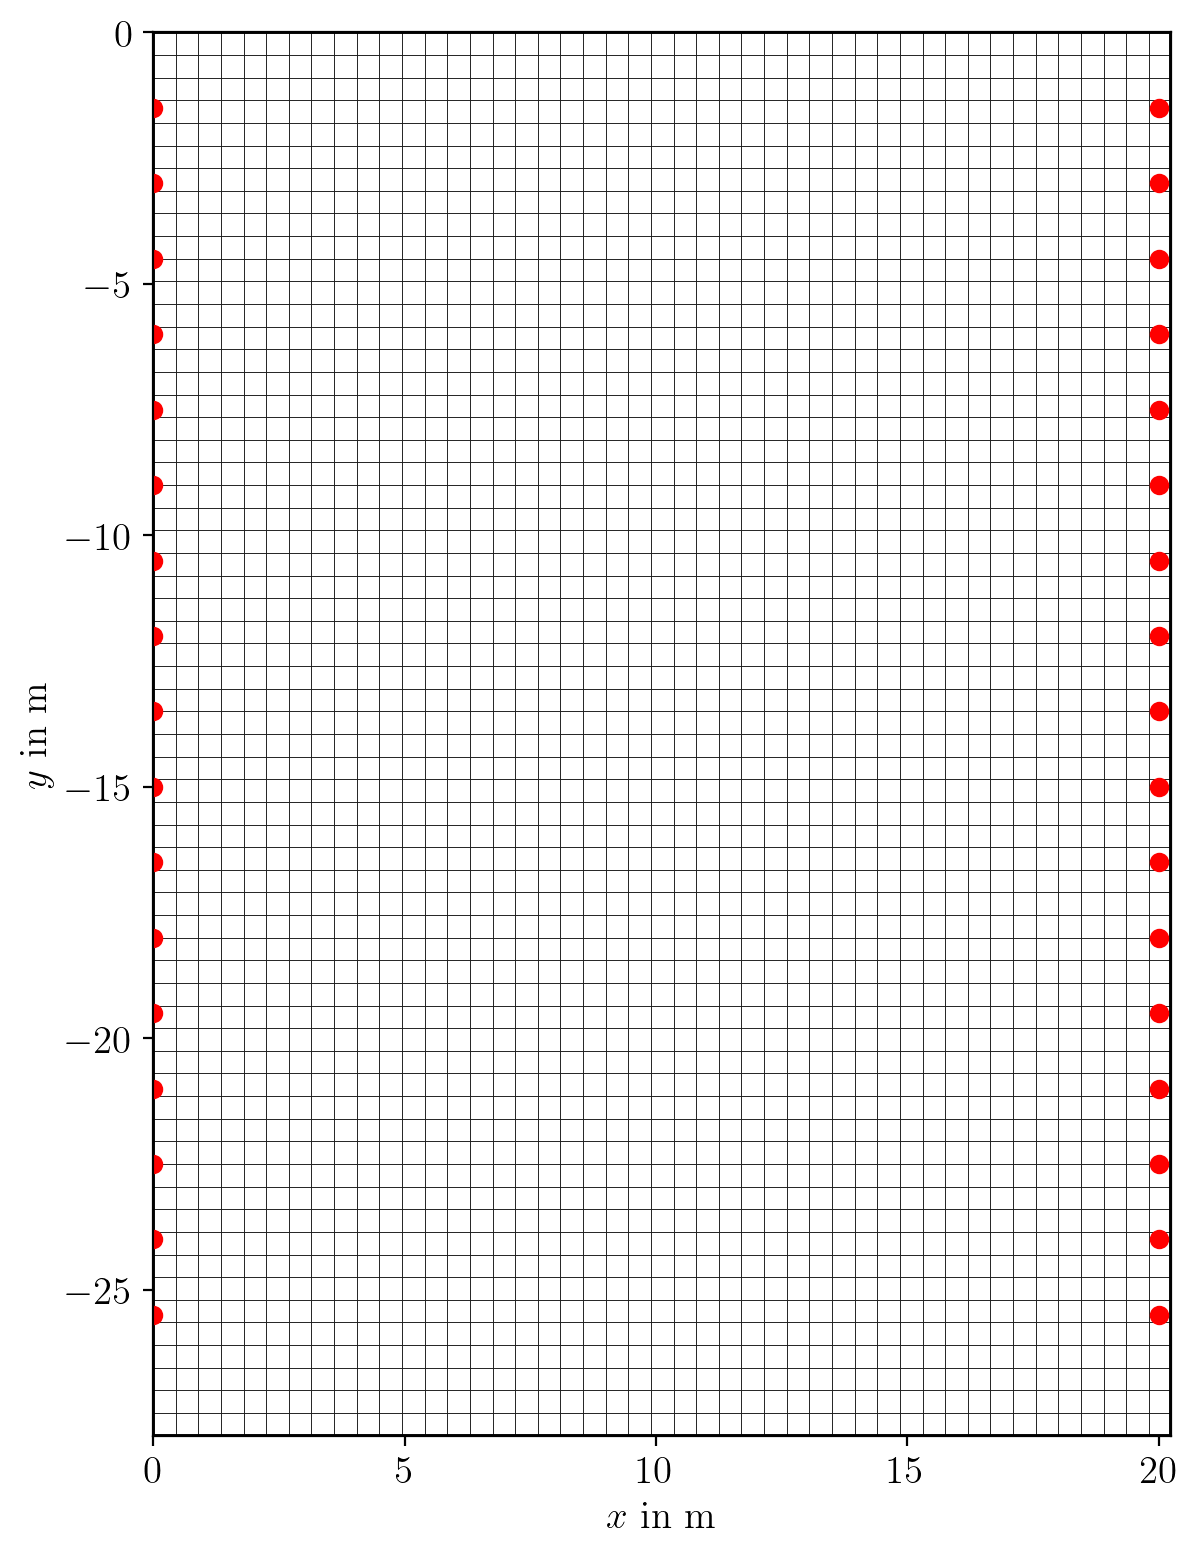

In [35]:
refinement = 0.3
x = np.arange(0, bh_spacing + refinement, sensor_spacing * refinement)
y = -np.arange(0.0, bh_length + 3, sensor_spacing * refinement)
mesh = pg.meshtools.createGrid(x, y)

fig, ax = plt.subplots(figsize=(12, 8))
ax, _ = pg.show(mesh, hold=True, ax=ax)
ax.plot(sensors[:, 0], sensors[:, 1], "ro")
plt.show()

In [36]:
invmodel = mgr.invert(data, mesh=mesh, secNodes=3, lam=1000, zWeight=1.0,
                      useGradient=False, verbose=True)
print("chi^2 = {:.2f}".format(mgr.inv.chi2()))

INFO:pyGIMLi:Found 1 regions.
06/11/25 - 17:41:08 - pyGIMLi - INFO - Found 1 regions.
INFO:pyGIMLi:Creating forward mesh from region infos.
06/11/25 - 17:41:08 - pyGIMLi - INFO - Creating forward mesh from region infos.
INFO:pyGIMLi:Creating refined mesh (secnodes: 3) to solve forward task.
06/11/25 - 17:41:09 - pyGIMLi - INFO - Creating refined mesh (secnodes: 3) to solve forward task.
INFO:pyGIMLi:Create constant starting model: 0.0005007263813993564
06/11/25 - 17:41:09 - pyGIMLi - INFO - Create constant starting model: 0.0005007263813993564
INFO:pyGIMLi:Created startmodel from forward operator:2790, min/max=0.000501/0.000501
06/11/25 - 17:41:09 - pyGIMLi - INFO - Created startmodel from forward operator:2790, min/max=0.000501/0.000501
INFO:pyGIMLi:Starting inversion.
06/11/25 - 17:41:09 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x7a899722f470>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.0097/0.02
min/max (error): 0.16%/0.2%
min/max (start model): 5.0e-04/5.0e-04
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  193.49
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   34.60 (dPhi = 80.82%) lam: 1000.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    3.99 (dPhi = 84.59%) lam: 1000.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.89 (dPhi = 42.31%) lam: 1000.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.26 (dPhi = 20.76%) lam: 1000.0
---------------------------------------------------------

The manager also holds the method showResult that is used to plot the result.
Note that only covered cells are shown by default.
For comparison we plot the geometry on top.



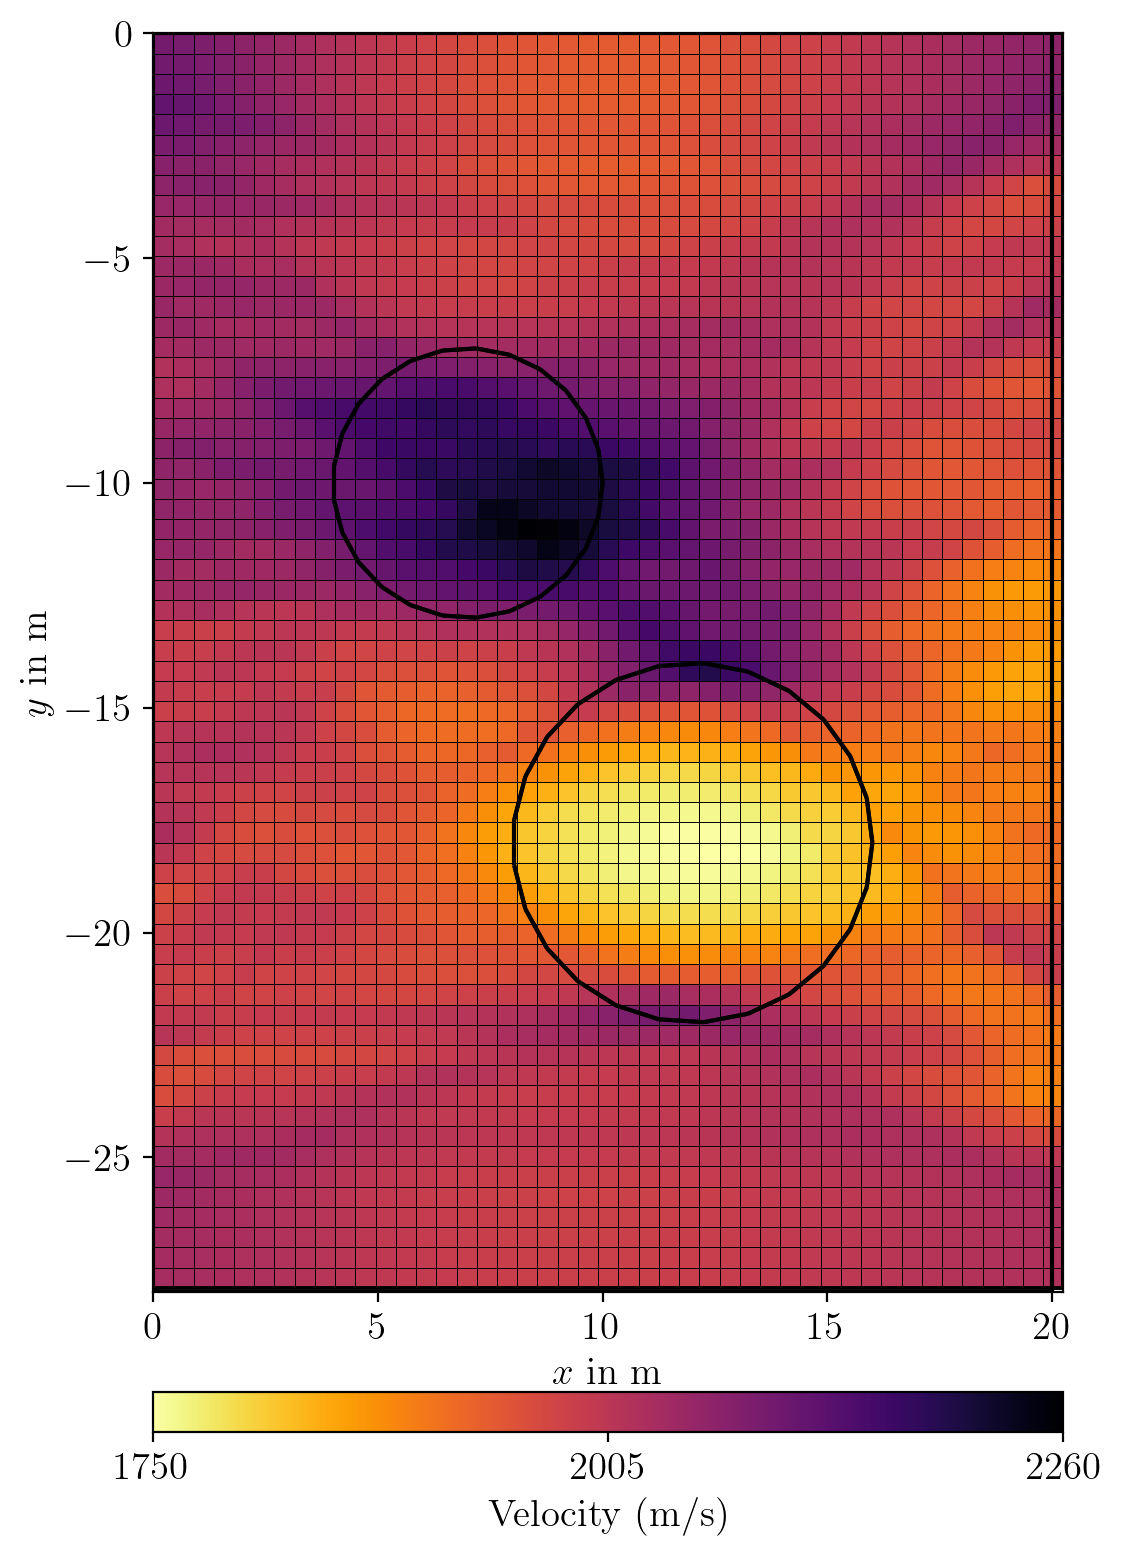

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
ax, _ = mgr.showResult(showMesh=True, logScale=False, ax=ax, nLevs=3, cMap="inferno_r")
ax, _ = pg.show(geom, ax=ax, fillRegion=False, regionMarker=False)

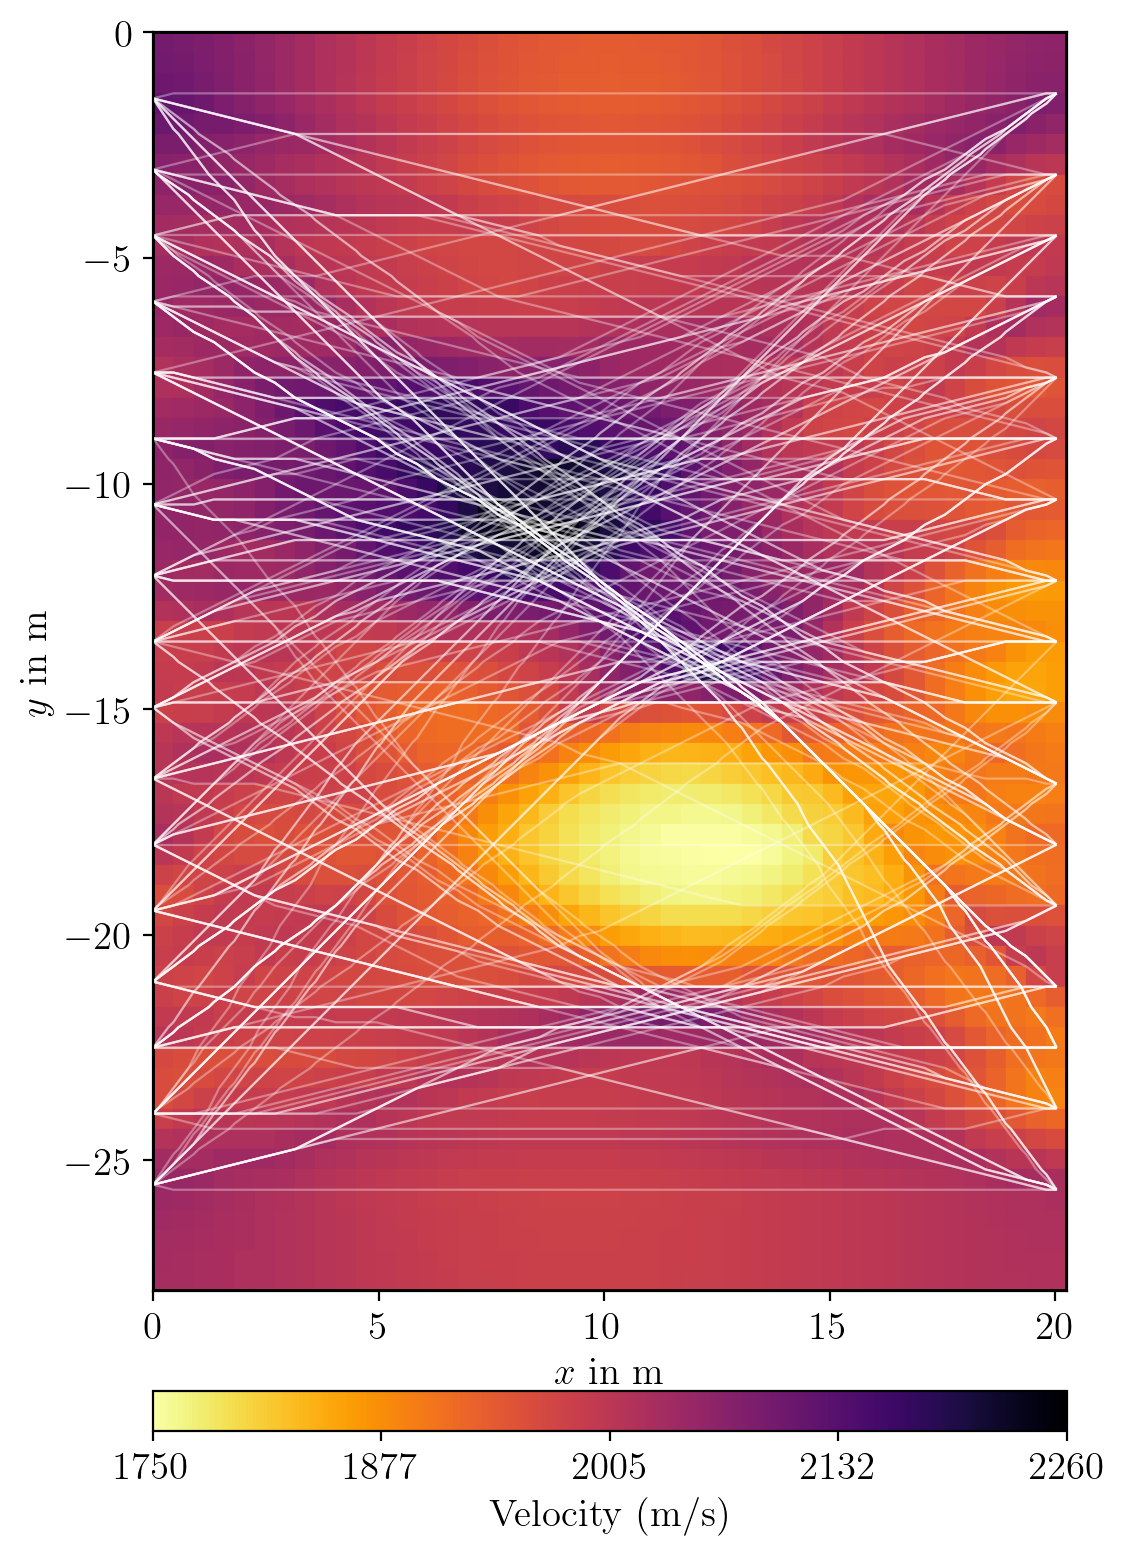

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))
ax, cbar = mgr.showResult(logScale=False, ax=ax, cMap="inferno_r")
rays = mgr.drawRayPaths(ax=ax, color="white",lw=0.8, alpha=0.35)

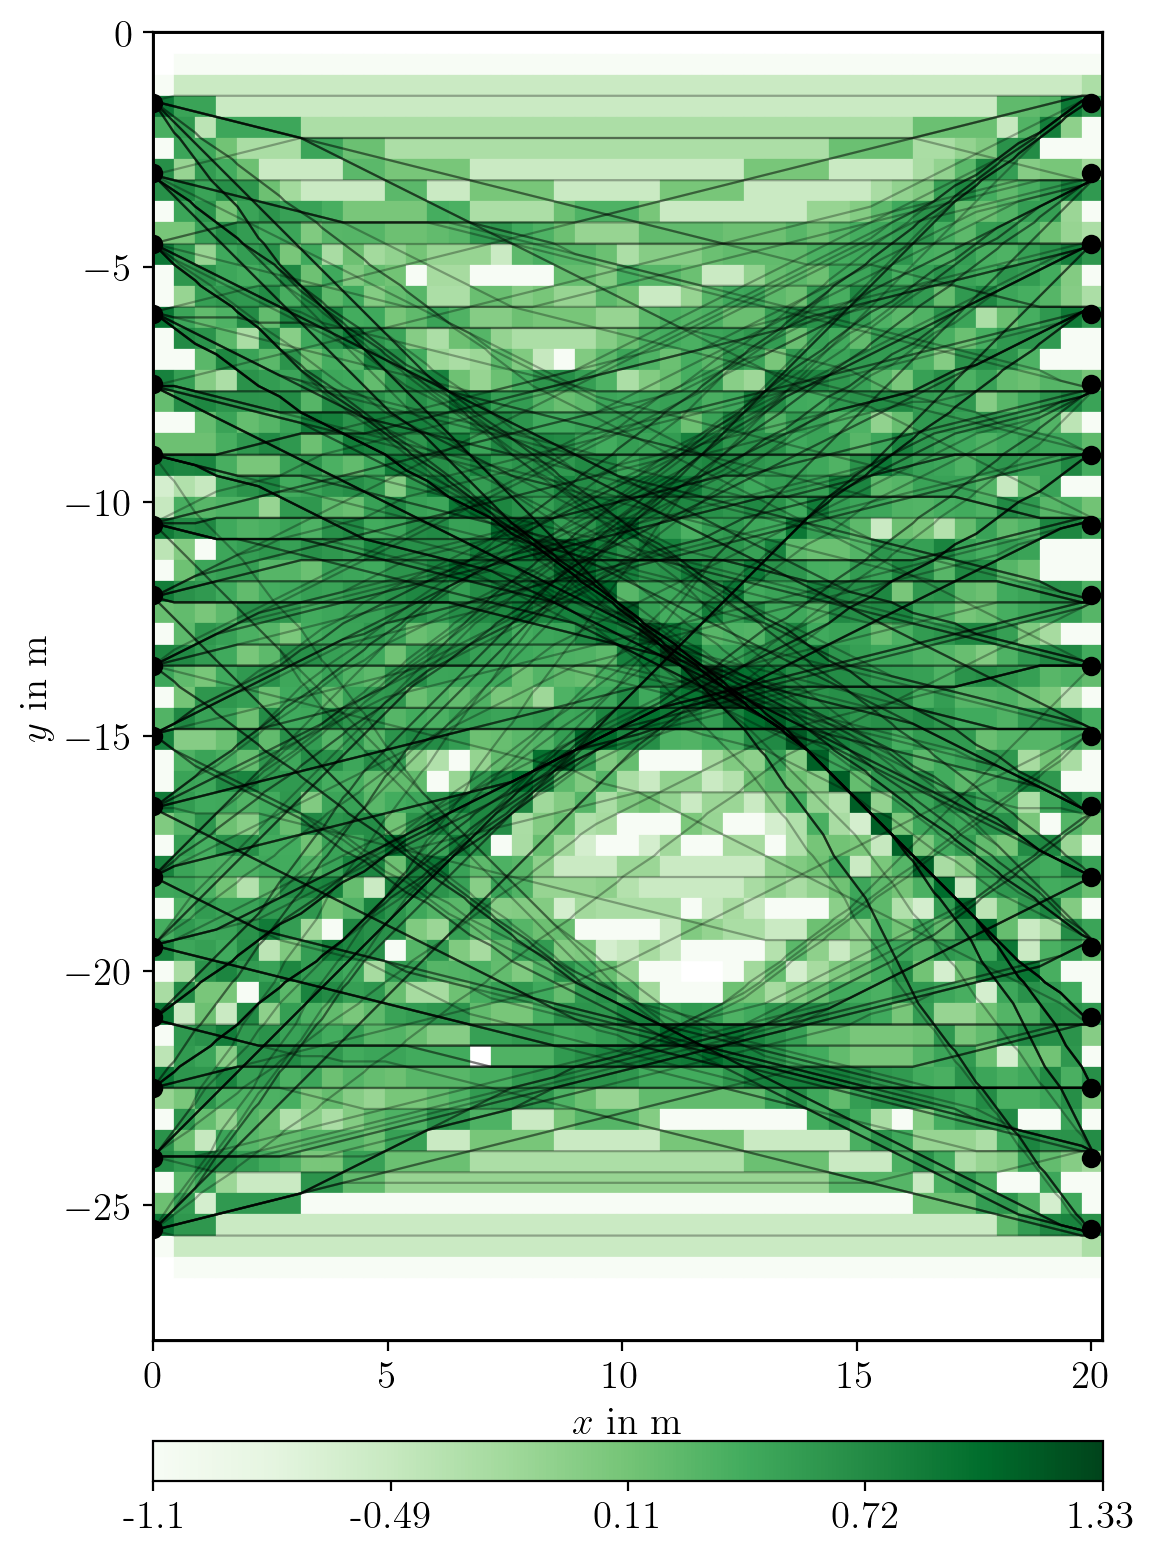

In [39]:
fig, ax = plt.subplots(figsize=(12,8))
mgr.showCoverage(ax=ax, cMap="Greens")
mgr.drawRayPaths(ax=ax, color="k", alpha=0.3)
p = ax.plot(sensors[:, 0], sensors[:, 1], "ko")